In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.signal import savgol_filter

from tabletop_py.gaze.preprocess import (
    clean_data,
    interpolate_markers,
    merge_eyelink_markers,
    reindex_steady_time,
)
from tabletop_py.gaze.visualize import (
    animate_2d_dots,
    animate_3d_dots,
    plot_eyelink_markers,
)

In [2]:
# session_dir = os.path.join(
#     os.environ["ROS_BAG_DIR"], "session_2025-08-12_15-19-30"
# )
session_dir = "/tabletop/bags/session_2025-08-22_02-22-51"
config_path = os.path.join(
    os.environ["TABLETOP_DIR"], "config", "gaze_calibration.yaml"
)
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

eyelink_path = os.path.join(session_dir, "eyelink_sample.csv")
markers_path = os.path.join(session_dir, "markers.csv")

eyelink_df = pd.read_csv(eyelink_path, index_col=False)
markers_df = pd.read_csv(markers_path, index_col=False)

eyelink_freq = config["preprocess"]["eyelink_freq"]
markers_freq = config["preprocess"]["markers_freq"]

In [124]:
def smooth_rolling(
    df: pd.DataFrame,
    columns: list[str],
    on: str,
    freq: float,
    window: float,
    on_unit: str = "s",
):
    df = df.copy()

    if df[on].dtype == float:
        df["datetime"] = pd.to_datetime(df[on], unit=on_unit)

    td = pd.to_timedelta(window, unit=on_unit)  # type: ignore
    rolling = df.rolling(
        on="datetime",
        center=True,
        window=td,
        min_periods=int(window * freq) - 1,
    )
    for col in columns:
        df[col] = rolling[col].mean()

    df = df.drop(columns=["datetime"])
    return df


def smooth_savgol(
    df: pd.DataFrame,
    columns: list[str],
    freq: float,
    on: str,
    window: float,
    polyorder: int = 3,
    deriv: int = 0,
):
    df = df.copy()

    df = reindex_steady_time(df, freq=freq, on=on, tolerance=1.1 / freq)

    if deriv > 0:
        delta = 1 / freq
    else:
        delta = 1.0

    window_length = int(window * freq)
    for col in columns:
        df[col] = savgol_filter(
            df[col],
            window_length=window_length,
            polyorder=polyorder,
            deriv=deriv,
            delta=delta,
        )
    return df


In [125]:
orig_df = pd.read_csv(os.path.join(session_dir, "preprocessed.csv"))
orig_df = orig_df[(orig_df["time"] > 29) & (orig_df["time"] < 40)]
orig_df.describe()

,time,left_x,left_y,right_x,right_y,marker_x,marker_y,marker_z
count,10659.000000,10659.000000,10659.000000,10659.000000,10659.000000,10659.000000,10659.000000,10659.000000
mean,34.638187,-5242.741707,-5588.661720,-4976.038781,-5809.615437,-0.133971,0.408539,0.432854
std,3.121772,1886.100491,1788.931641,1855.045648,1802.500836,0.058362,0.069397,0.071082
min,29.000263,-8485.000000,-9598.000000,-8555.000000,-9814.000000,-0.256017,0.309346,0.334017
25%,31.937763,-7114.000000,-6957.305876,-6789.358970,-7185.763198,-0.185059,0.340666,0.360361
50%,34.669263,-5386.000000,-5596.589402,-5009.149916,-5823.369282,-0.110747,0.407553,0.430843
75%,37.334763,-3356.000000,-3912.685918,-3163.563636,-4092.765974,-0.084618,0.475982,0.503416
max,39.999263,-1981.667155,-2864.000000,-1861.000000,-3085.000000,-0.073488,0.510931,0.538188


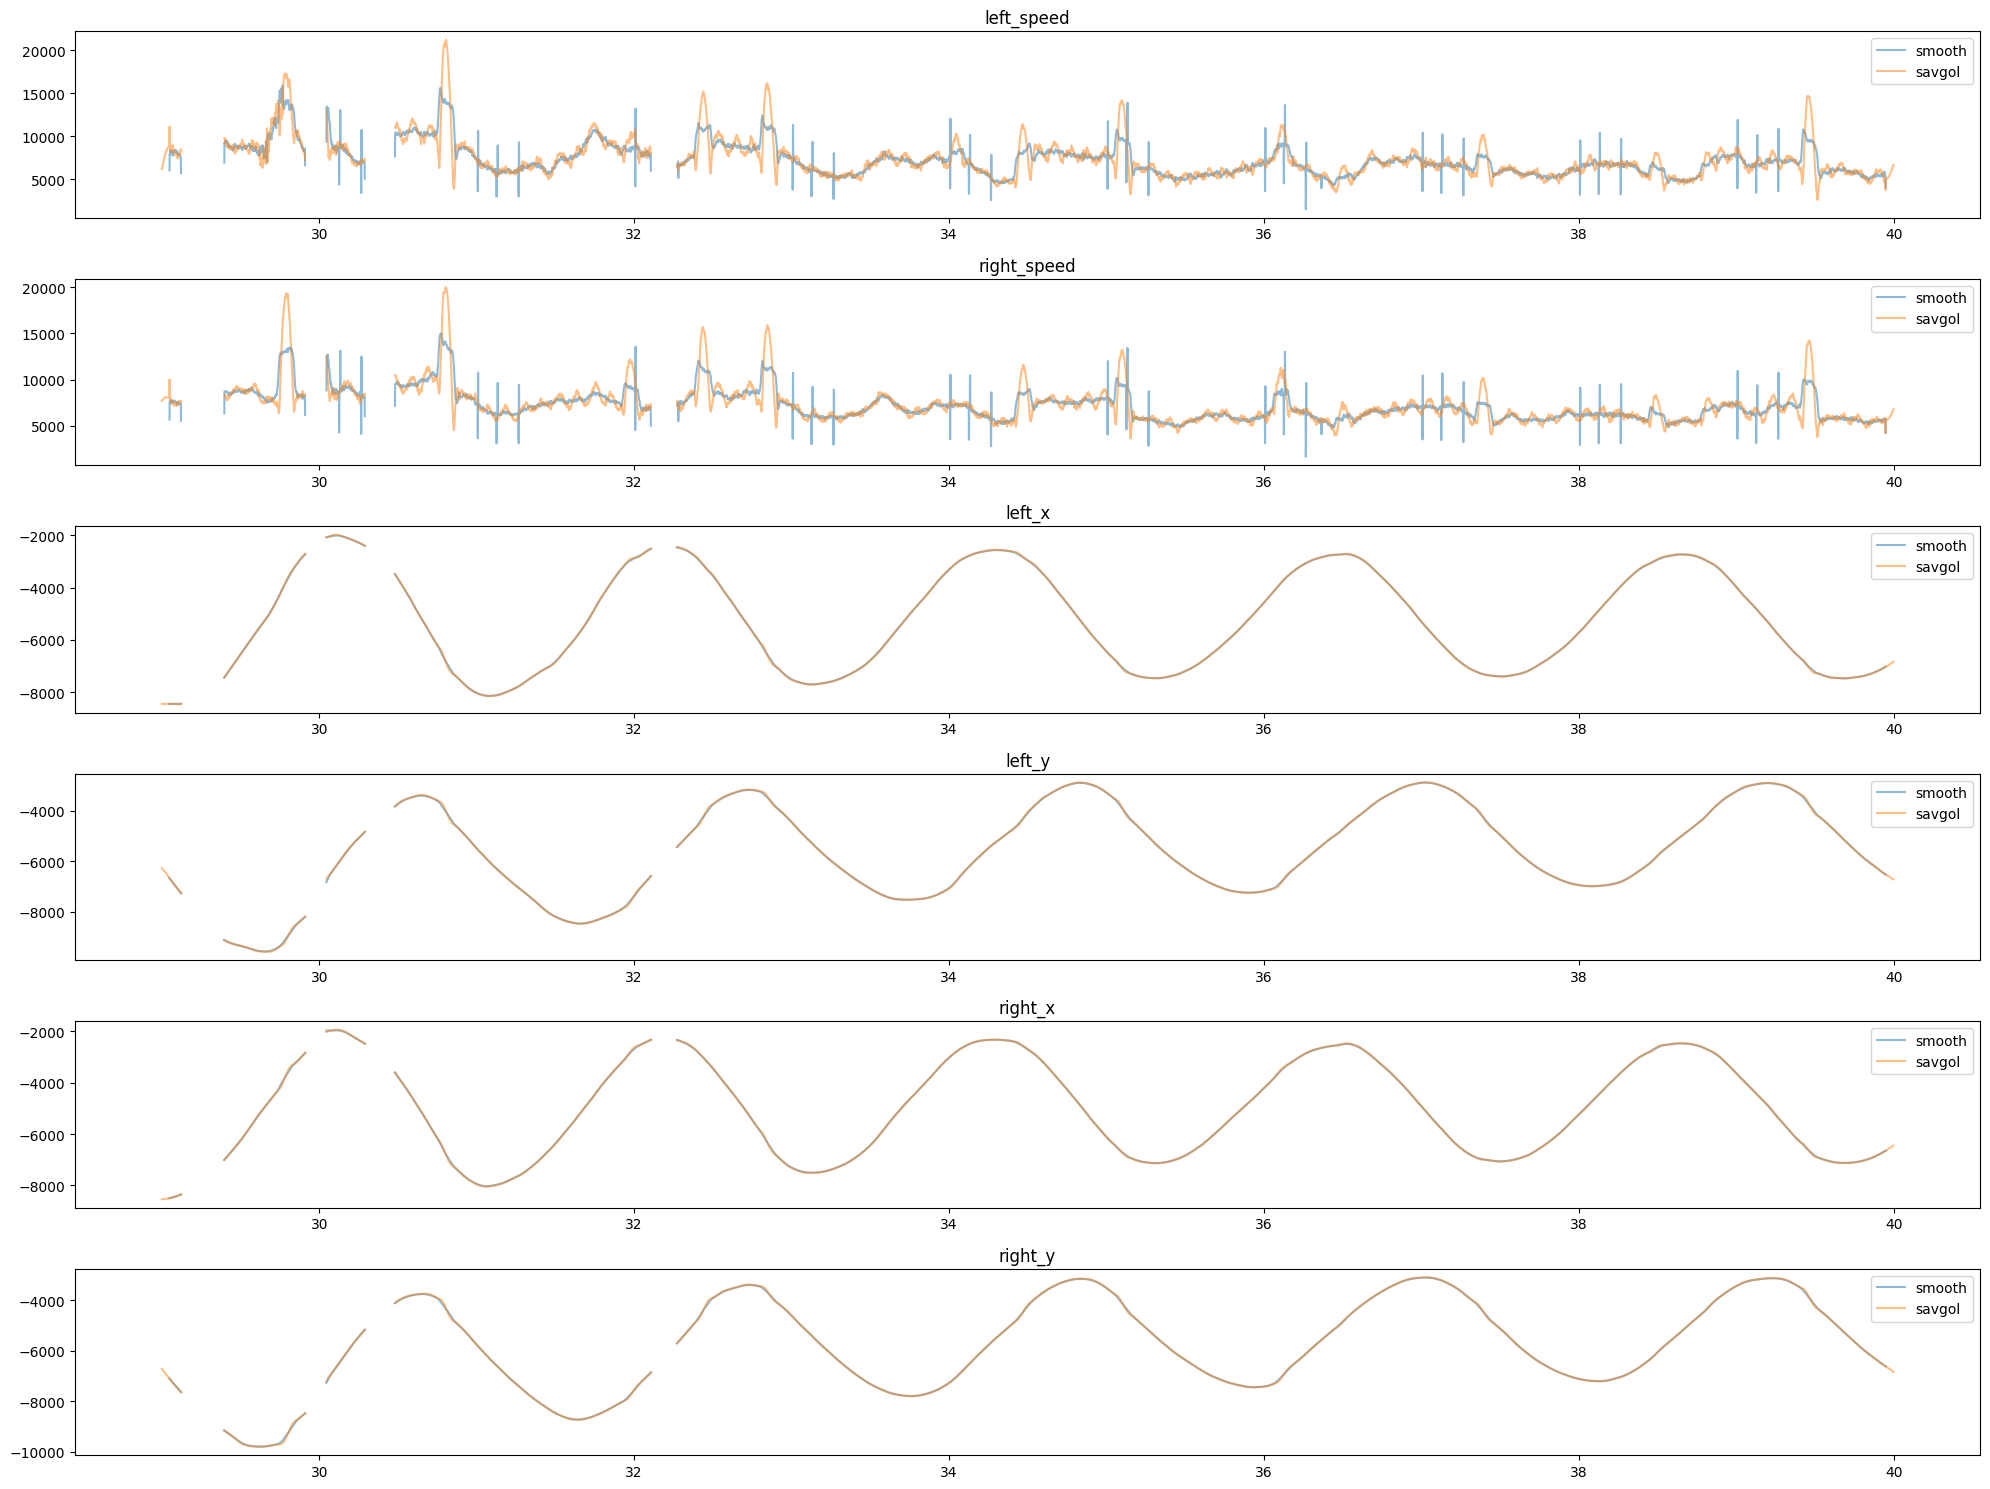

In [126]:
smooth_df = smooth_rolling(
    orig_df,  # type: ignore
    columns=["left_x", "left_y", "right_x", "right_y"],
    on="time",
    freq=eyelink_freq,
    window=0.1,
    on_unit="s",
)

savgol_df = smooth_savgol(
    orig_df,  # type: ignore
    columns=["left_x", "left_y", "right_x", "right_y"],
    freq=eyelink_freq,
    on="time",
    window=0.1,
)

dfs = {"orig": orig_df, "smooth": smooth_df, "savgol": savgol_df}
for name, df in dfs.items():
    df["left_speed"] = np.linalg.norm(
        np.gradient(df[["left_x", "left_y"]], df["time"], axis=0), axis=1
    )
    df["right_speed"] = np.linalg.norm(
        np.gradient(df[["right_x", "right_y"]], df["time"], axis=0), axis=1
    )

dfs = {}
# dfs["orig"] = orig_df
dfs["smooth"] = smooth_df
dfs["savgol"] = savgol_df
columns = []
columns.extend(["left_speed", "right_speed"])
columns.extend(["left_x", "left_y", "right_x", "right_y"])
fig, axs = plt.subplots(len(columns), 1, figsize=(20, 15 * len(columns) / 6))
for name, df in dfs.items():
    for i, col in enumerate(columns):
        axs[i].plot(
            df["time"], df[col], ls="-", alpha=1 / len(dfs), label=name
        )
        axs[i].set_title(col)
        axs[i].legend()
plt.tight_layout()

In [26]:
df[df["left_speed"] <= 0]

,time,left_x,left_y,right_x,right_y,marker_x,marker_y,marker_z,left_speed,right_speed
380,12.395263,-6470.930750,-7358.138500,-6120.000000,-7484.168998,-0.134092,0.330473,0.377559,-1132.397640,3415.556128
791,12.806263,-3757.000000,-7324.045879,-3420.458789,-7424.000000,-0.125806,0.326966,0.490779,-40.245345,22585.055329
877,12.892263,-3216.000000,-6909.082223,-2968.082223,-7042.000000,-0.124140,0.344342,0.510831,-420.293321,11111.189203
2656,14.671263,-5890.928860,-7375.000000,-5393.569122,-7370.000000,-0.086532,0.315982,0.407173,-1333.529854,11012.008427
2961,14.976263,-3615.000000,-6701.134139,-3336.865861,-6844.000000,-0.084640,0.328456,0.494017,-242.248953,1098.868360
...,...,...,...,...,...,...,...,...,...,...
104659,123.043263,-2901.000000,-5588.271140,-2649.000000,-5851.000000,-0.081222,0.371035,0.529031,-644.009828,1596.534824
105100,123.484263,-3450.592434,-3576.000000,-3224.592434,-3769.000000,-0.085892,0.483509,0.505598,-202.146411,1894.608249
105283,123.667263,-4513.000000,-2954.850923,-4160.087071,-3153.447230,-0.087190,0.506986,0.464790,-447.949544,10508.571385
105357,123.741263,-5090.267584,-2849.133792,-4748.140670,-3125.267584,-0.087753,0.510541,0.439859,-306.128786,10637.623521


In [ ]:
eyelink_df, markers_df = format_timestamps(
    eyelink_df, markers_df, eyelink_freq, markers_freq
)

In [ ]:
eyelink_df, markers_df = clean_data(eyelink_df, markers_df, marker_idx=0)
df = merge_eyelink_markers(eyelink_df, markers_df)
df = interpolate_markers(df)

In [ ]:
df

In [ ]:
plot_eyelink_markers(df, df)

In [ ]:
arr = df[["left_x", "left_y", "right_x", "right_y"]].values
arr = arr.reshape(arr.shape[0], 2, 2)

In [ ]:
animate_2d_dots(arr, 1000, save_path="eyelink.mp4")

In [ ]:
arr = df[["marker_x", "marker_y", "marker_z"]].values
arr = arr.reshape(arr.shape[0], 1, 3)

In [ ]:
animate_3d_dots(arr, 1000, save_path="markers.mp4")